# Segments

Where the model works and for whom. Risk deciles and cumulative default capture show ranking quality; subgroup AUC checks it holds across age, income, and gender.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from src.data import load_selected, RAW
from src.models import oof

X, y_all = load_selected()
p = pd.Series(oof(lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                           n_jobs=-1, verbose=-1), X, y_all), index=X.index, name="p_default")
app = pd.read_csv(RAW / "application_train.csv",
                  usecols=["SK_ID_CURR", "TARGET", "CODE_GENDER", "DAYS_BIRTH", "AMT_INCOME_TOTAL"]).set_index("SK_ID_CURR")
df = app.join(p).dropna(subset=["p_default"])
y = df["TARGET"]
df["age"] = (-df["DAYS_BIRTH"] / 365).round()
df.shape

(307511, 6)

## Risk deciles

In [2]:
df["decile"] = pd.qcut(df["p_default"], 10, labels=False)
df.groupby("decile").agg(avg_p=("p_default", "mean"), default_rate=("TARGET", "mean"), n=("TARGET", "size")).round(4)

,avg_p,default_rate,n
decile,,,
0,0.0097,0.0079,30752
1,0.0162,0.0149,30751
2,0.0225,0.0214,30751
3,0.0298,0.0270,30751
4,0.0391,0.0390,30751
5,0.0516,0.0522,30751
6,0.0696,0.0739,30751
7,0.0980,0.1050,30751
8,0.1499,0.1566,30751


## Cumulative default capture

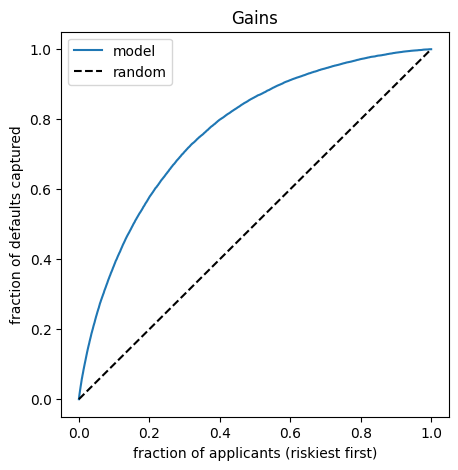

In [3]:
order = df.sort_values("p_default", ascending=False)
cum = order["TARGET"].cumsum() / order["TARGET"].sum()
frac = np.arange(1, len(order) + 1) / len(order)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(frac, cum.values, label="model")
ax.plot([0, 1], [0, 1], "k--", label="random")
ax.set(xlabel="fraction of applicants (riskiest first)", ylabel="fraction of defaults captured", title="Gains")
ax.legend(); plt.show()

## Subgroup AUC

In [4]:
def sub_auc(mask):
    return round(roc_auc_score(y[mask], df["p_default"][mask]), 4) if y[mask].nunique() == 2 else np.nan

df["age_band"] = pd.cut(df["age"], [0, 30, 40, 50, 60, 100])
df["income_band"] = pd.qcut(df["AMT_INCOME_TOTAL"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
rows = []
for g in ["M", "F"]:
    rows.append({"segment": f"gender={g}", "n": int((df.CODE_GENDER == g).sum()), "auc": sub_auc(df.CODE_GENDER == g)})
for b in df["age_band"].cat.categories:
    rows.append({"segment": f"age={b}", "n": int((df.age_band == b).sum()), "auc": sub_auc(df.age_band == b)})
for b in ["Q1", "Q2", "Q3", "Q4"]:
    rows.append({"segment": f"income={b}", "n": int((df.income_band == b).sum()), "auc": sub_auc(df.income_band == b)})
pd.DataFrame(rows)

,segment,n,auc
0,gender=M,105059,0.7847
1,gender=F,202448,0.7928
2,"age=(0, 30]",48869,0.7679
3,"age=(30, 40]",82770,0.7953
4,"age=(40, 50]",75509,0.7965
5,"age=(50, 60]",67955,0.7865
6,"age=(60, 100]",32408,0.7520
7,income=Q1,100578,0.7941
8,income=Q2,53182,0.7925
9,income=Q3,82213,0.7908


## Where do the purchased scores add the most?

Score an internal-only model and the full model out-of-fold, then read the external lift (combined AUC minus internal AUC) within each segment. The thesis predicts the biggest lift for thin-file and younger applicants, where the lender's own data is sparse.

In [5]:
ext = [c for c in X.columns if "ext_source" in c.lower() or c.lower().startswith("ext_calc_")]
internal = [c for c in X.columns if c not in ext]
gbm = lgb.LGBMClassifier(n_estimators=800, learning_rate=0.03, num_leaves=31, min_child_samples=50,
                         subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=2.0,
                         n_jobs=-1, verbose=-1)
df["p_internal"] = pd.Series(oof(gbm, X[internal], y_all), index=X.index).reindex(df.index)
thickness = X[internal].notna().sum(axis=1)
df["file"] = np.where(thickness.reindex(df.index) < thickness.median(), "thin", "thick")
print("internal-only OOF scored")

internal-only OOF scored


In [6]:
def seg_lift(mask):
    yy = y[mask]
    if yy.nunique() != 2: return (np.nan, np.nan, np.nan)
    ai = roc_auc_score(yy, df["p_internal"][mask]); ac = roc_auc_score(yy, df["p_default"][mask])
    return round(ai, 4), round(ac, 4), round(ac - ai, 4)

segs = [("all", pd.Series(True, index=df.index))]
segs += [(f"file={v}", df.file == v) for v in ["thin", "thick"]]
segs += [(f"age={b}", df.age_band == b) for b in df.age_band.cat.categories]
segs += [(f"gender={g}", df.CODE_GENDER == g) for g in ["M", "F"]]
rows = []
for name, mask in segs:
    ai, ac, l = seg_lift(mask)
    rows.append({"segment": name, "n": int(mask.sum()), "internal_auc": ai, "combined_auc": ac, "external_lift": l})
pd.DataFrame(rows)

,segment,n,internal_auc,combined_auc,external_lift
0,all,307511,0.7693,0.7936,0.0243
1,file=thin,153645,0.7675,0.7955,0.0280
2,file=thick,153866,0.7700,0.7911,0.0211
3,"age=(0, 30]",48869,0.7400,0.7679,0.0279
4,"age=(30, 40]",82770,0.7659,0.7953,0.0294
5,"age=(40, 50]",75509,0.7729,0.7965,0.0236
6,"age=(50, 60]",67955,0.7661,0.7865,0.0204
7,"age=(60, 100]",32408,0.7245,0.7520,0.0275
8,gender=M,105059,0.7594,0.7847,0.0253
9,gender=F,202448,0.7680,0.7928,0.0248
